In [ ]:
Exercise 3

In [ ]:
Problem Statement

The function plot_data() reads precision and recall values from a CSV file and plots a precision-recall curve. However, the resulting graph does not correspond to the values stored in the file.

In [ ]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time

In [ ]:
 Bug Analysis
The values read from the CSV file are stored as strings rather than numeric values.
    results.append(row)
    results = np.stack(results)
The resulting array contains text values such as:
'0.013'
'0.951'
instead of floating-point numbers.

In [1]:
import csv

f = open("data_file.csv", "w", newline='')
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
print("CSV created successfully!")

CSV created successfully!


In [2]:
import os
print(os.getcwd())  

C:\Users\soura


In [3]:
import csv
import numpy as np

results = []
with open('data_file.csv') as result_csv:
    csv_reader = csv.reader(result_csv, delimiter=',')
    next(csv_reader)
    for row in csv_reader:
        results.append(row)
print(type(results[0][0])) 
print(results[:3])           

<class 'str'>
[['0.013', '0.951'], ['0.376', '0.851'], ['0.441', '0.839']]


In [4]:
results_array = np.stack(results)
print(results_array.dtype)   

<U5


In [5]:
results_fixed = []
with open('data_file.csv') as result_csv:
    csv_reader = csv.reader(result_csv, delimiter=',')
    next(csv_reader)
    for row in csv_reader:
        results_fixed.append([float(val) for val in row]) 

results_fixed = np.stack(results_fixed)
print(results_fixed.dtype)  

float64


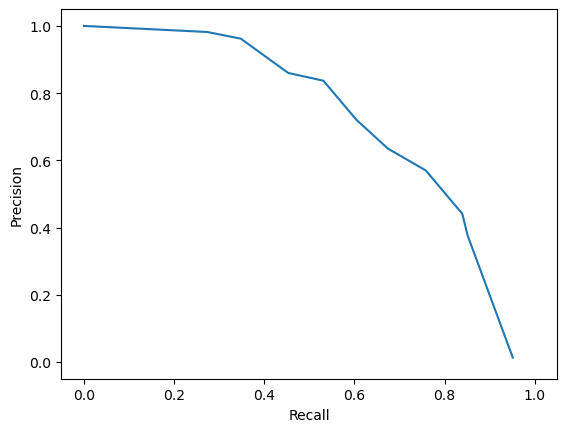

In [6]:
import matplotlib.pyplot as plt

plt.plot(results_fixed[:, 1], results_fixed[:, 0])
plt.ylim([-0.05, 1.05])
plt.xlim([-0.05, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [ ]:
Conclusion

The graph was incorrect because the CSV data was loaded as strings rather than floating-point numbers. Converting the values to floats and plotting the correct columns resolves the issue and produces an accurate precision-recall curve.